# Make Poster Figures for CSUMB end of summer showcase


### import dependencies

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

## Load combined water_year wbet dataframe, apply qc filters, and compute stats

* Apply quality filters
* Filter for data after 2015 to ensure ET data are only from OpenET Collections v2.1
* Filter hucs with more than 5 water_years
* compute ET standard deviation, precipitation mean and standard deviation.
* group values by huc 8

In [2]:
all_df = pd.read_csv('results/tables/combined_wbet_water_year.csv')
wy_counts = all_df.loc[all_df.water_year>2015][['huc8','water_year']].groupby('huc8').count()
huc8s_filtered = wy_counts.loc[wy_counts.water_year>=5].index.to_list()
filtered_df = all_df.loc[all_df.water_year>2015][all_df['huc8'].isin(huc8s_filtered)]

### Average and standard deviation across precipitation products, compute standard deviation across ET models
wbet_cols = filtered_df.columns[filtered_df.columns.str.startswith("wbet_")]
et_cols = filtered_df.columns[filtered_df.columns.str.endswith("_et_mm")]
pr_cols = filtered_df.columns[filtered_df.columns.str.endswith("_precipitation_mm")]

filtered_df["wbet_mean"] = filtered_df[wbet_cols].mean(axis=1)
filtered_df["wbet_std"] = filtered_df[wbet_cols].std(axis=1)
filtered_df["wbet_cov"] = filtered_df['wbet_std']/filtered_df['wbet_mean']

filtered_df["et_std"] = filtered_df[et_cols].std(axis=1)
filtered_df["et_cov"] = filtered_df['et_std']/filtered_df['ensemble_et_mm']

filtered_df["et_ratio"] = filtered_df['ensemble_et_mm']/filtered_df['wbet_mean']


filtered_df["pr_mean"] = filtered_df[pr_cols].mean(axis=1)
filtered_df["pr_std"] = filtered_df[pr_cols].std(axis=1)
filtered_df["pr_cov"] = filtered_df['pr_std']/filtered_df['pr_mean']
filtered_df['q_pr_ratio']=filtered_df['q_mm']/filtered_df['pr_mean']


### Average across the 
filter_df_mean = filtered_df.groupby('huc8').mean()

/var/folders/xf/b124_hpd62s6q61gr4dvlkyr0000gn/T/ipykernel_9188/3760030837.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_df = all_df.loc[all_df.water_year>2015][all_df['huc8'].isin(huc8s_filtered)]


### Load ancilary data
land use fractions
* agland
* forrest
* grassland

elevation
* elevation (m)
* standard deviation in elevation (m)

compute Q/Pr ratio
* ratio indicates average fraction of precipitation

In [3]:
lu_df = pd.read_csv('data/ancillary/huc8_cdl_landuse_fractions_2023.csv')
elev_df = pd.read_csv('data/ancillary/huc8_elevation_stats.csv')

df_match1 = filter_df_mean.join(
    elev_df.set_index("HUC8_id"),
    how="inner")

df_match2 = df_match1.join(
    lu_df.set_index("HUC8_id"),
    how="inner")


df_match2.columns

Index(['water_year', 'AgEra-5_precipitation_mm', 'prism_precipitation_mm',
       'rdpa_precipitation_mm', 'nclimgrid_precipitation_mm',
       'gridmet_precipitation_mm', 'chirps_precipitation_mm', 'ensemble_et_mm',
       'disalexi_et_mm', 'eemetric_et_mm', 'ptjpl_et_mm', 'ssebop_et_mm',
       'geesebal_et_mm', 'q_mm', 'wbet_AgEra-5_mm', 'wbet_prism_mm',
       'wbet_rdpa_mm', 'wbet_nclimgrid_mm', 'wbet_gridmet_mm',
       'wbet_chirps_mm', 'wbet_mean', 'wbet_std', 'wbet_cov', 'et_std',
       'et_cov', 'et_ratio', 'pr_mean', 'pr_std', 'pr_cov', 'q_pr_ratio',
       'elev_mean', 'elev_std', 'agland_fraction', 'forrest_fraction',
       'grassland_fraction'],
      dtype='object')

### Plot multi-year average ET (y-axis) vs WBET (x-axis)
Whiskers indicate standard deviation of ET and WBET

Text(0, 0.5, 'OpenET Ensemble ET (mm)')

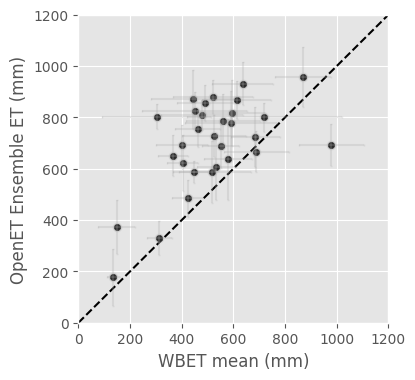

In [4]:
plt.style.use('ggplot')
fig, ax1 = plt.subplots(1,1, figsize = (4,4))
ones = np.arange(0,1300,50)

plt.plot(ones,ones, linestyle = '--',color='k')
ax1.errorbar(
    x=df_match2["wbet_mean"],
    y=df_match2["ensemble_et_mm"],
    xerr=df_match2["wbet_std"],
    yerr=df_match2["et_std"],
    fmt="o",
    # linestyle="None",
    capsize=1,
    alpha=0.25,
    color='darkgray'
)
df_match2.plot.scatter(x='wbet_mean',y='ensemble_et_mm',color='k',ax=ax1)

ax1.set_xlim(0, 1200)
ax1.set_ylim(0, 1200)
ax1.set_xlabel("WBET mean (mm)")
ax1.set_ylabel("OpenET Ensemble ET (mm)")

## Plot multi-year average ET (y-axis) vs WBET (x-axis)
#### Whiskers indicate standard deviation of ET and WBET

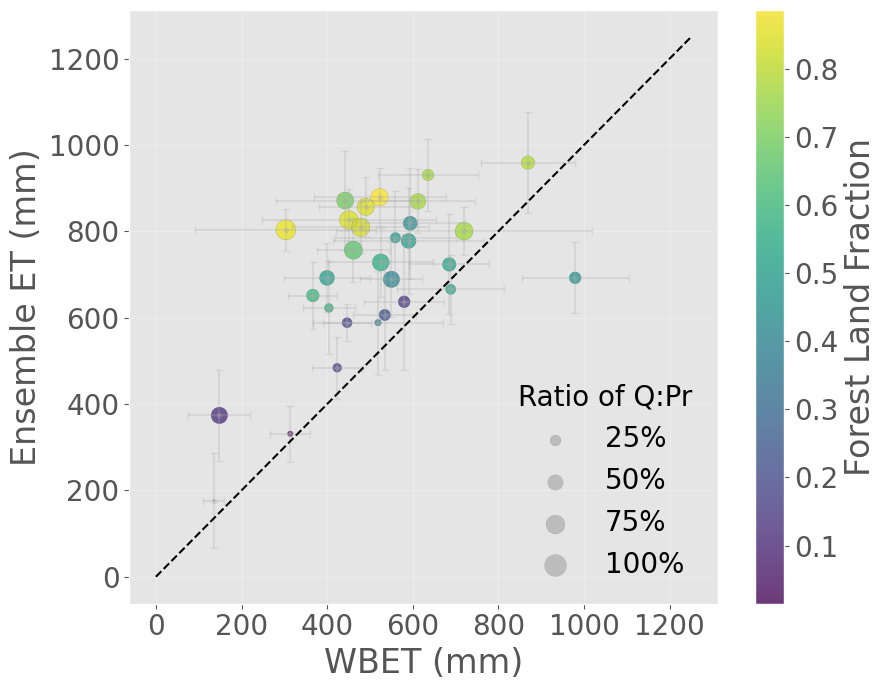

In [16]:
df = df_match2.copy()
import matplotlib.pyplot as plt

# Adjust this value to control the maximum marker size
size_scale = 250

fig, ax = plt.subplots(figsize=(9, 7))

ax.errorbar(
    x=df["wbet_mean"],
    y=df["ensemble_et_mm"],
    xerr=df["wbet_std"],
    yerr=df["et_std"],
    fmt=".",
    # linestyle="none",
    capsize=3,
    alpha=0.25,
    color='darkgray'
)

scatter = ax.scatter(
    df["wbet_mean"],
    df["ensemble_et_mm"],  # Replace if the actual column name differs
    s=df["q_pr_ratio"].clip(0, 1) * size_scale,
    c=df["forrest_fraction"],
    cmap="viridis",
    alpha=0.75,
    edgecolors="black",
    linewidths=0.1
)
ax.plot(ones,ones,linestyle='--',color='k')

ax.set_xlabel("WBET (mm)", fontsize=24)
ax.set_ylabel("Ensemble ET (mm)", fontsize=24)

colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label("Forest Land Fraction", fontsize=24)
colorbar.ax.tick_params(labelsize=20)

# Example marker-size legend
fractions = [0.25, 0.50, 0.75, 1.00]

size_handles = [
    ax.scatter(
        [],
        [],
        s=fraction * size_scale,
        color="gray",
        alpha=0.4,
        edgecolors="black",
        linewidths=0.1,
        label=f"{fraction:.0%}"
    )
    for fraction in fractions
]
ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=20)

ax.legend(
    handles=size_handles,
    fontsize=20,
    title="Ratio of Q:Pr",
    title_fontsize=20,       
    loc="best",
    frameon=False
)

ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()
fig.savefig('results/figures/OpenET_WBET_scatter_forest_fracANDratioQPr.png',dpi=150)

### Table join to shapefile to save for ArcPro Figures

In [113]:
gdf = gpd.read_file('data/geo/study_area.shp')
gdf["study_ar_4"] = (
    gdf["study_ar_4"]
    .astype("string")
    .str.strip()
    .str.zfill(8)
)
gdf["study_ar_4"] = gdf.study_ar_4.astype('int')


In [115]:
df_join = df.copy().reset_index()

gdf2=gdf.merge(df_join, right_on="index", left_on='study_ar_4', how="inner")
gdf2.to_file('data/geo/huc8_wbet.shp')



/var/folders/xf/b124_hpd62s6q61gr4dvlkyr0000gn/T/ipykernel_98630/2710713300.py:4: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf2.to_file('data/geo/huc8_wbet.shp')
/opt/homebrew/Cellar/jupyterlab/3.4.7/libexec/lib/python3.10/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'AgEra-5_precipitation_mm' to 'AgEra-5_pr'
  ogr_write(
/opt/homebrew/Cellar/jupyterlab/3.4.7/libexec/lib/python3.10/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'prism_precipitation_mm' to 'prism_prec'
  ogr_write(
/opt/homebrew/Cellar/jupyterlab/3.4.7/libexec/lib/python3.10/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'rdpa_precipitation_mm' to 'rdpa_preci'
  ogr_write(
/opt/homebrew/Cellar/jupyterlab/3.4.7/libexec/lib/python3.10/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'nclimgrid_precipitation_mm' to 'nclim

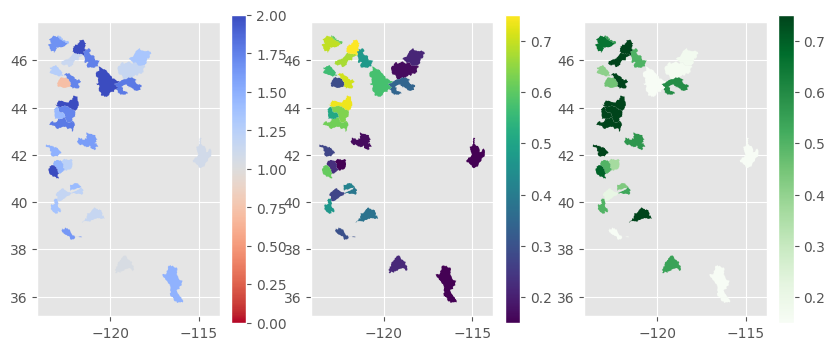

In [126]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Border colors based on Selected_3
border_colors = {
    "low": "red",
    "medium": "yellow",
    "high": "green",
}
edge_colors = (
    gdf2["Selected_3"]
    .str.lower()
    .map(border_colors)
    .fillna("black")  # fallback for missing or unexpected values
)


fig, ax = plt.subplots(1,3, figsize=(10, 4))

gdf2.plot(
    column="et_ratio",
    ax=ax[0],
    vmin=0,vmax=2,
    legend=True,
    cmap="coolwarm_r"
)

gdf2.plot(
    column="q_pr_ratio",
    ax=ax[1],
    vmin=0.15,vmax=0.75,
    legend=True,
    cmap="viridis"
)

gdf2.plot(
    column="forrest_fraction",
    ax=ax[2],
    legend=True,
    vmin=0.15, vmax=0.75,
    cmap="Greens"
)

plt.show()

0     636.705080
1     826.130816
2     930.446454
3     176.383368
4     622.553052
5     777.678080
6     588.387263
7     784.967269
8     871.261285
9     959.016432
10    818.560792
11    606.218761
12    723.239815
13    800.434924
14    692.226073
15    856.740582
16    878.817981
17    484.028155
18    651.309300
19    373.618044
20    869.447767
21    692.200459
22    809.376170
23    588.294208
24    756.408383
25    727.994991
26    331.112634
27    803.441359
28    665.676845
29    688.720980
Name: ensemble_et_mm, dtype: float64

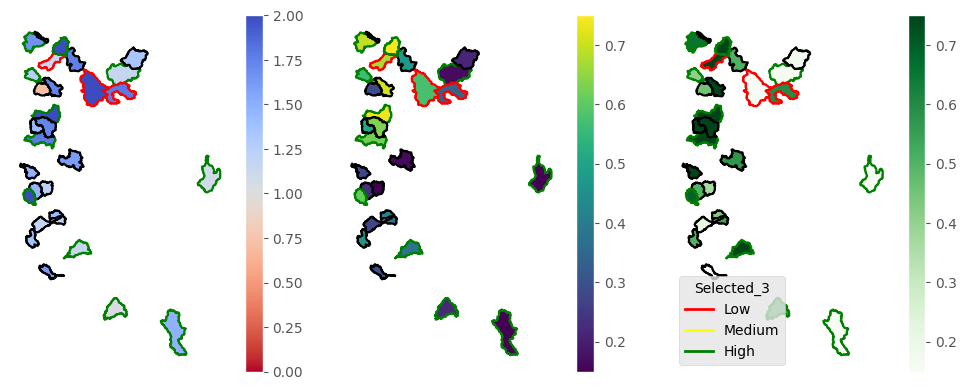

In [136]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Border colors based on Selected_3
border_colors = {
    "low": "red",
    "medium": "yellow",
    "high": "green",
}

edge_colors = (
    gdf2["Selected_3"]
    .str.lower()
    .map(border_colors)
    .fillna("black")  # fallback for missing or unexpected values
)

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

gdf2.plot(
    column="et_ratio",
    ax=ax[0],
    vmin=0,
    vmax=2,
    legend=True,
    cmap="coolwarm_r",
    edgecolor=edge_colors,
    linewidth=1.5,
)

gdf2.plot(
    column="q_pr_ratio",
    ax=ax[1],
    vmin=0.15,
    vmax=0.75,
    legend=True,
    cmap="viridis",
    edgecolor=edge_colors,
    linewidth=1.5,
)

gdf2.plot(
    column="forrest_fraction",
    ax=ax[2],
    vmin=0.15,
    vmax=0.75,
    legend=True,
    cmap="Greens",
    edgecolor=edge_colors,
    linewidth=1.5,
)

# Optional legend explaining the border colors
border_legend = [
    Line2D([0], [0], color="red", linewidth=2, label="Low"),
    Line2D([0], [0], color="yellow", linewidth=2, label="Medium"),
    Line2D([0], [0], color="green", linewidth=2, label="High"),
]

ax[2].legend(
    handles=border_legend,
    title="Selected_3",
    loc="lower left",
)

for axis in ax:
    axis.set_axis_off()

plt.tight_layout()
plt.show()